In [4]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from scipy.linalg import lu, qr, svd, null_space

# 工具函数
def tensor_product(matrices):
    """计算多个矩阵的张量积"""
    return reduce(np.kron, matrices)


def annihilation_operator(N, site):
    """
    构造N格点系统中第site个格点的湮灭算符
    
    参数:
        N: 格点总数
        site: 格点索引 (0-based)
    
    返回:
        a_i: 2^N × 2^N 矩阵
    """
    # Jordan-Wigner变换因子
    sigma_z = np.array([[1, 0], [0, -1]])
    
    # 构造弦算符 (site之前的所有格点)
    operators = []
    for j in range(N):
        if j < site:
            operators.append(sigma_z)  # 弦算符部分
        elif j == site:
            operators.append(np.array([[0, 1], [0, 0]]))  # 湮灭算符
        else:
            operators.append(np.eye(2))  # 单位矩阵
    
    # 计算Kronecker积
    result = operators[0]
    for op in operators[1:]:
        result = np.kron(result, op)
    
    return result

def creation_operator(N, site):
    """
    构造N格点系统中第site个格点的产生算符
    """
    return annihilation_operator(N, site).conj().T

def number_operator(N, site):
    """
    构造占据数算符 n_i = a_i† a_i
    """
    a = annihilation_operator(N, site)
    a_dag = creation_operator(N, site)
    return a_dag @ a


def build_hamiltonian(L, J):
    """构建最近邻跃迁哈密顿量"""
    H = np.zeros((2**L, 2**L), dtype=complex)
    # 最近邻跃迁项
    for i in range(L-1):
        H_hop = -J *(creation_operator(L, i) @ annihilation_operator(L, i+1) + creation_operator(L, i+1) @ annihilation_operator(L, i))
        H += H_hop
    

    H += -J *(creation_operator(L, L-1) @ annihilation_operator(L, 0) + creation_operator(L, 0) @ annihilation_operator(L, L-1))
    return H

def build_lindblad_operators(L, gamma):
    """构建单向跃迁Lindblad算符"""
    lindblad_ops = []
    for i in range(L):
        L_op = np.sqrt(gamma) * annihilation_operator(L, i)
        lindblad_ops.append(L_op)
    
    return lindblad_ops


def build_lindblad_k(L, gamma, k):
    lindblad_ops = []
    if k==1:
        for i in range(L):
            L_op = np.sqrt(gamma) * creation_operator(L, i)
            lindblad_ops.append(L_op)
    elif k==2:
        for i in range(L):
            for j in range(L):
                if j < i:
                    L_op = np.sqrt(gamma)*creation_operator(L, i) @ creation_operator(L, j)
                    lindblad_ops.append(L_op)
    elif k==3:
        for i in range(L):
            for j in range(L):
                for k in range(L):
                    if j < i and k < j:
                        L_op = np.sqrt(gamma)*creation_operator(L, i) @ creation_operator(L, j) @creation_operator(L, k)
                        lindblad_ops.append(L_op)

    elif k==4:
        lindblad_ops.append(np.sqrt(gamma)*creation_operator(L, 3)@creation_operator(L, 2)@creation_operator(L, 1)@creation_operator(L, 0))
    return lindblad_ops


def build_liouville_superoperator(H, lindblad_ops, a, q, lindblad_ops_k):
    dim = H.shape[0]
    L_super = np.zeros((dim**2, dim**2), dtype=complex)
    I = np.eye(dim)
    L_super += -1j * (np.kron(H - 1j*a*I/2, I) - np.kron(I, (H+1j*a*I/2).T))
    for L_op in lindblad_ops:
        L_super += np.kron(L_op, L_op.conj())
    for L_op in lindblad_ops_k:
        L_super += q * np.kron(L_op, L_op.conj())
    return L_super

def compute_liouville_eigenvalues(H, lindblad_ops, a, q, lindblad_ops_k):
    """计算Liouville超算符的本征值"""
    L_super = build_liouville_superoperator(H, lindblad_ops, a, q, lindblad_ops_k)
    eigenvalues, eigenvectors = np.linalg.eig(L_super)
    return eigenvalues, eigenvectors, L_super

def plot_liouville_spectrum_vs_gamma(L, J, gamma, a, k):
    """绘制Liouville本征值谱随耗散强度的变化""" 
    all_eigenvalues = []
    lindblad_ops = build_lindblad_operators(L, gamma)
    lindblad_ops_k = build_lindblad_k(L, gamma, k)
    H = build_hamiltonian(L, J)
    q = np.arange(0, 0.1, 1e-4)
    for i in q:
        print(i)
        eigenvalues, _, _ = compute_liouville_eigenvalues(H, lindblad_ops, a, i, lindblad_ops_k)
        re = np.sort(eigenvalues.real)
        all_eigenvalues.append(re[-1]-re[-2])
    all_eigenvalues = np.array(all_eigenvalues).flatten()
    Re, Im = np.real(all_eigenvalues), np.imag(eigenvalues)
    np.savetxt('ReEigenk{}.txt'.format(k), Re)# FIg2

def main():
    """主函数"""
    # 系统参数
    L = 4 # 格点数
    J = 1  # 跃迁强度
    gamma = 2
    a = 0
    # 绘制Liouville谱随耗散强度的变化
    print("计算Liouville本征值谱随耗散强度的变化...")
    for k in [1,2,3,4]:
        plot_liouville_spectrum_vs_gamma(L, J, gamma, a, k)
if __name__ == "__main__":
    main()

计算Liouville本征值谱随耗散强度的变化...
0.0
0.0001
0.0002
0.00030000000000000003
0.0004
0.0005
0.0006000000000000001
0.0007
0.0008
0.0009000000000000001
0.001
0.0011
0.0012000000000000001
0.0013000000000000002
0.0014
0.0015
0.0016
0.0017000000000000001
0.0018000000000000002
0.0019
0.002
0.0021000000000000003
0.0022
0.0023
0.0024000000000000002
0.0025
0.0026000000000000003
0.0027
0.0028
0.0029000000000000002
0.003
0.0031000000000000003
0.0032
0.0033
0.0034000000000000002
0.0035
0.0036000000000000003
0.0037
0.0038
0.0039000000000000003
0.004
0.0041
0.004200000000000001
0.0043
0.0044
0.0045000000000000005
0.0046
0.0047
0.0048000000000000004
0.0049
0.005
0.0051
0.005200000000000001
0.0053
0.0054
0.0055000000000000005
0.0056
0.0057
0.0058000000000000005
0.0059
0.006
0.0061
0.006200000000000001
0.0063
0.0064
0.006500000000000001
0.0066
0.0067
0.0068000000000000005
0.006900000000000001
0.007
0.0071
0.007200000000000001
0.0073
0.0074
0.007500000000000001
0.0076
0.0077
0.0078000000000000005
0.0079
0.008
0.0

<>:304: SyntaxWarning: invalid escape sequence '\i'
<>:304: SyntaxWarning: invalid escape sequence '\i'
/var/folders/kp/0cqs6yg572jgfkspzdc39y6r0000gn/T/ipykernel_11652/3061173515.py:304: SyntaxWarning: invalid escape sequence '\i'
  axes.set_ylabel('log($N(t)-N(\infty)$)') # 指数增长


构建系统算符...
初始态信息:
  叠加系数: α=1.0, β=1.0
  真空态分量: 0.0000
  单粒子态分量: 1.0000
开始直接数值求解...
求解完成
初始态信息:
  叠加系数: α=1.0, β=1.0
  真空态分量: 0.0000
  单粒子态分量: 1.0000
开始直接数值求解...
求解完成
初始态信息:
  叠加系数: α=1.0, β=1.0
  真空态分量: 0.0000
  单粒子态分量: 1.0000
开始直接数值求解...
求解完成
初始态信息:
  叠加系数: α=1.0, β=1.0
  真空态分量: 0.0000
  单粒子态分量: 1.0000
开始直接数值求解...
求解完成
初始态信息:
  叠加系数: α=1.0, β=1.0
  真空态分量: 0.0000
  单粒子态分量: 1.0000
开始直接数值求解...
求解完成


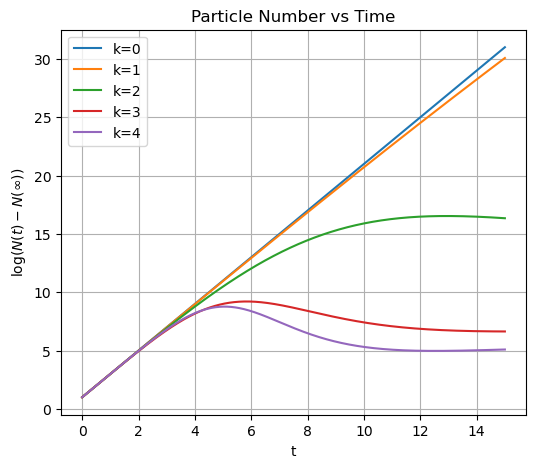

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from scipy.optimize import curve_fit


# 工具函数
def tensor_product(matrices):
    """计算多个矩阵的张量积"""
    return reduce(np.kron, matrices)

def annihilation_operator(N, site):
    """
    构造N格点系统中第site个格点的湮灭算符
    
    参数:
        N: 格点总数
        site: 格点索引 (0-based)
    
    返回:
        a_i: 2^N × 2^N 矩阵
    """
    # Jordan-Wigner变换因子
    sigma_z = np.array([[1, 0], [0, -1]])
    
    # 构造弦算符 (site之前的所有格点)
    operators = []
    for j in range(N):
        if j < site:
            operators.append(sigma_z)  # 弦算符部分
        elif j == site:
            operators.append(np.array([[0, 1], [0, 0]]))  # 湮灭算符
        else:
            operators.append(np.eye(2))  # 单位矩阵
    
    # 计算Kronecker积
    result = operators[0]
    for op in operators[1:]:
        result = np.kron(result, op)
    
    return result

def creation_operator(N, site):
    """
    构造N格点系统中第site个格点的产生算符
    """
    return annihilation_operator(N, site).conj().T

def number_operator(N, site):
    """
    构造占据数算符 n_i = a_i† a_i
    """
    a = annihilation_operator(N, site)
    a_dag = creation_operator(N, site)
    return a_dag @ a

def build_hamiltonian(L, J):
    """构建最近邻跃迁哈密顿量"""
    H = np.eye(2**L, dtype=complex)
    for i in range(L-1):
        H_hop = -J *(creation_operator(L, i) @ annihilation_operator(L, i+1) + creation_operator(L, i+1) @ annihilation_operator(L, i))
        H += H_hop
    
    H += -J *(creation_operator(L, L-1) @ annihilation_operator(L, 0) + creation_operator(L, 0) @ annihilation_operator(L, L-1))
    return H

def build_lindblad_operators(L, gamma):
    """构建单向跃迁Lindblad算符"""
    lindblad_ops = []
    for i in range(L):
        L_op = np.sqrt(gamma) * annihilation_operator(L, i)
        lindblad_ops.append(L_op)
    return lindblad_ops

def build_lindblad_k(L, gamma, k):
    lindblad_ops = []
    if k==1:
        for i in range(L):
            L_op = np.sqrt(gamma) * creation_operator(L, i)
            lindblad_ops.append(L_op)
    elif k==2:
        for i in range(L):
            for j in range(L):
                if j < i:
                    L_op = np.sqrt(gamma)*creation_operator(L, i) @ creation_operator(L, j)
                    lindblad_ops.append(L_op)
    elif k==3:
        for i in range(L):
            for j in range(L):
                for k in range(L):
                    if j < i and k < j:
                        L_op = np.sqrt(gamma)*creation_operator(L, i) @ creation_operator(L, j) @creation_operator(L, k)
                        lindblad_ops.append(L_op)

    elif k==4:
        lindblad_ops.append(np.sqrt(gamma)*creation_operator(L, 3)@creation_operator(L, 2)@creation_operator(L, 1)@creation_operator(L, 0))
    return lindblad_ops

def lindblad_superoperator(H, lindblad_ops, rho, q, lindblad_ops_k):
    """计算Lindblad超算符作用在密度矩阵上的结果"""
    # 哈密顿量演化项
    comm_H = -1j * (H @ rho - rho @ H)
    
    # Lindblad耗散项
    diss = np.zeros_like(rho, dtype=complex)
    for L_op in lindblad_ops:
        L_dag = L_op.conj().T
        diss += L_op @ rho @ L_dag - (L_op @ L_dag + L_dag @ L_op) @ rho 
    for L_op in lindblad_ops_k:
        L_dag = L_op.conj().T
        diss += q * L_op @ rho @ L_dag
    return comm_H + diss

def normalize_density_matrix(rho):
    """归一化密度矩阵"""
    trace = np.trace(rho)
    if abs(trace) > 1e-12:
        return rho / trace
    else:
        return rho


def rk4_step(rho, H, lindblad_ops, dt, q, lindblad_ops_k):
    """使用四阶Runge-Kutta方法进行一步时间演化"""
    def f(t, rho, q):
        return lindblad_superoperator(H, lindblad_ops, rho, q, lindblad_ops_k)
    
    k1 = f(0, rho, q)
    k2 = f(0, rho + 0.5*dt*k1, q)
    k3 = f(0, rho + 0.5*dt*k2, q)
    k4 = f(0, rho + dt*k3, q)
    
    rho_new = rho + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)
    
    # 确保厄米性和归一化
    rho_new = normalize_density_matrix(rho_new)
    
    return rho_new

def solve_lindblad_direct(H, lindblad_ops, rho0, t_span, num_steps, q, lindblad_ops_k):
    """直接数值求解Lindblad方程"""
    t_start, t_end = t_span
    dt = (t_end - t_start) / num_steps
    t_values = np.linspace(t_start, t_end, num_steps + 1)
    
    states = [rho0]
    current_rho = rho0.copy()
    
    for i in range(num_steps):
        current_rho = rk4_step(current_rho, H, lindblad_ops, dt, q, lindblad_ops_k)
        states.append(current_rho)
    return t_values, states

def expectation_value(op, state):
    """计算算符的期望值"""
    return np.trace(op @ state).real

def create_initial_state(L, superposition_type, alpha=1.0, beta=1.0):
    """创建初始态
    
    Parameters:
    -----------
    L : int
        格点数
    superposition_type : str
        叠加态类型: "vacuum_single" (真空态和单粒子态叠加)
    alpha, beta : complex
        叠加系数
    """
    dim = 2**L
    
    if superposition_type == "vacuum_single":
        # 真空态 |0⟩
        vacuum = np.zeros(dim, dtype=complex)
        vacuum[0] = 1.0
        
        # 单粒子态 (在第一个格点)
        single_particle = np.zeros(dim, dtype=complex)
        single_particle[1] = 1.0  # 二进制: 001 (第一个格点占据)
        
        # 叠加态: α|0⟩ + β|1⟩
        psi = alpha * vacuum + beta * single_particle
        
        # 归一化
        norm = np.sqrt(np.abs(alpha)**2 + np.abs(beta)**2)
        psi = psi / norm
        
    else:
        # 默认使用原来的方法
        occupied_sites = [0]
        state_index = 0
        for site in occupied_sites:
            state_index += 2**site
        psi = np.zeros(dim, dtype=complex)
        psi[state_index] = 1.0
    
    # 转换为密度矩阵
    rho = np.outer(psi, psi.conj())
    
    print(f"初始态信息:")
    print(f"  叠加系数: α={alpha}, β={beta}")
    #print(f"  归一化系数: 1/{norm:.4f}")
    print(f"  真空态分量: {np.abs(psi[0]):.4f}")
    print(f"  单粒子态分量: {np.abs(psi[1]):.4f}")
    
    return rho

def create_low_particle_state(L, max_particle_expectation):
    """创建总粒子数期望值小于1的任意初态
    
    Parameters:
    -----------
    L : int
        格点数
    max_particle_expectation : float
        最大允许的总粒子数期望值
    """
    dim = 2**L
    def get_total_particle_number(state, L):
        """获取总粒子数期望值"""
        total = 0
        for i in range(L):
            total += get_particle_number(state, i, L)
        return total
    
    # 创建随机叠加态
    np.random.seed(33)  # 为了可重复性
    
    # 生成随机复数系数
    random_coeffs = np.random.randn(dim) + 1j * np.random.randn(dim)
    
    # 确保真空态有较大的权重
    random_coeffs[0] = random_coeffs[0] # 增加真空态的权重
    
    # 归一化波函数
    norm = np.sqrt(np.sum(np.abs(random_coeffs)**2))
    psi = random_coeffs / norm
    
    # 转换为密度矩阵
    rho = np.outer(psi, psi.conj())
    
    # 计算当前的总粒子数期望值
    current_total = get_total_particle_number(rho, L)
    
    # 如果总粒子数期望值大于目标值，调整系数
    if current_total > max_particle_expectation:
        # 减小单粒子态和双粒子态的权重
        for i in range(1, dim):
            # 计算态i的粒子数
            particle_count = bin(i).count("1")
            # 根据粒子数调整系数
            reduction_factor = 1.0 / (particle_count + 1)
            psi[i] = psi[i] * reduction_factor
        
        # 重新归一化
        norm = np.sqrt(np.sum(np.abs(psi)**2))
        psi = psi / norm
        
        # 更新密度矩阵
        rho = np.outer(psi, psi.conj())
    
    # 最终的总粒子数期望值
    final_total = get_total_particle_number(rho, L)
    
    print(f"创建的初态信息:")
    print(f"  目标最大粒子数期望值: {max_particle_expectation}")
    print(f"  实际总粒子数期望值: {final_total:.4f}")
    
    # 打印各个粒子数分量的概率
    particle_probs = {}
    for i in range(dim):
        particle_count = bin(i).count("1")
        prob = np.abs(psi[i])**2
        if particle_count in particle_probs:
            particle_probs[particle_count] += prob
        else:
            particle_probs[particle_count] = prob
    
    print(f"  各粒子数分量的概率:")
    for count, prob in sorted(particle_probs.items()):
        print(f"    {count} 粒子态: {prob:.4f}")
    
    return rho

def get_particle_number(state, site, L):
    """获取特定格点的粒子数期望值"""
    n_op = number_operator(L, site)
    return expectation_value(n_op, state)

def plot_results(t_values, states, L, gamma, q, k):
    """绘制结果"""
    
    # 粒子数分布随时间变化
    particle_numbers = np.array([[get_particle_number(state, i, L) 
                                for state in states] for i in range(L)])
    tot_number = particle_numbers[0, :]
    for i in range(L):
        if i > 0:
            tot_number += particle_numbers[i, :]
    axes.set_xlabel('t')
    axes.set_title('Particle Number vs Time')
    axes.grid(True)
    # 归一密度矩阵
    axes.set_ylabel('log($N(t)-N(\infty)$)') # 指数增长
    axes.plot(t_values, 1/tot_number, label='k={}'.format(k)) # 指数增长
    np.savetxt('1Totnumberk{}.txt'.format(k), tot_number)
    # 未归一密度矩阵
    #axes.set_ylabel('log$N(t)+L\gamma t$') # 能看出多项式的
    #axes.plot(t_values, np.log(np.exp(L*gamma*t_values)*tot_number), label='q={}'.format(q)) # 能看出多项式的
    return fig

def main():
    """主函数"""
    # 系统参数
    L = 4 # # 格点数
    J, gamma, q = 1, 2, 1e-5  # 跃迁强度 耗散强度
    T = 15.0  # 总时间
    num_steps = int(100*T)  # 时间步数
    print("构建系统算符...")
    # 构建系统算符
    H = build_hamiltonian(L, J)
    lindblad_ops = build_lindblad_operators(L, gamma)
    for k in [0, 1, 2, 3, 4]:
        # 初始状态：真空态和单粒子态的叠加
        # 可以调整alpha和beta来改变叠加权重
        alpha = 1.0  # 真空态系数
        beta = 1.0   # 单粒子态系数
        lindblad_ops_k = build_lindblad_k(L, gamma, k)
        rho0 = create_initial_state(L, superposition_type="vacuum_single11", alpha=alpha, beta=beta)
        print("开始直接数值求解...")
        t_values, states = solve_lindblad_direct(H, lindblad_ops, rho0, (0, T), num_steps, q, lindblad_ops_k)
        print("求解完成")
        # 绘制结果
        plot_results(t_values, states, L, gamma, q, k)
    axes.legend()
    plt.show()


fig, axes = plt.subplots(1, 1, figsize=(6, 5))
main()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from scipy.linalg import lu, qr, svd, null_space

# 工具函数
def tensor_product(matrices):
    """计算多个矩阵的张量积"""
    return reduce(np.kron, matrices)


def annihilation_operator(N, site):
    """
    构造N格点系统中第site个格点的湮灭算符
    
    参数:
        N: 格点总数
        site: 格点索引 (0-based)
    
    返回:
        a_i: 2^N × 2^N 矩阵
    """
    # Jordan-Wigner变换因子
    sigma_z = np.array([[1, 0], [0, -1]])
    
    # 构造弦算符 (site之前的所有格点)
    operators = []
    for j in range(N):
        if j < site:
            operators.append(sigma_z)  # 弦算符部分
        elif j == site:
            operators.append(np.array([[0, 1], [0, 0]]))  # 湮灭算符
        else:
            operators.append(np.eye(2))  # 单位矩阵
    
    # 计算Kronecker积
    result = operators[0]
    for op in operators[1:]:
        result = np.kron(result, op)
    
    return result

def creation_operator(N, site):
    """
    构造N格点系统中第site个格点的产生算符
    """
    return annihilation_operator(N, site).conj().T

def number_operator(N, site):
    """
    构造占据数算符 n_i = a_i† a_i
    """
    a = annihilation_operator(N, site)
    a_dag = creation_operator(N, site)
    return a_dag @ a


def build_hamiltonian(L, J):
    """构建最近邻跃迁哈密顿量"""
    H = np.zeros((2**L, 2**L), dtype=complex)
    # 最近邻跃迁项
    for i in range(L-1):
        H_hop = -J *(creation_operator(L, i) @ annihilation_operator(L, i+1) + creation_operator(L, i+1) @ annihilation_operator(L, i))
        H += H_hop
    

    H += -J *(creation_operator(L, L-1) @ annihilation_operator(L, 0) + creation_operator(L, 0) @ annihilation_operator(L, L-1))
    return H

def build_lindblad_operators(L, gamma):
    """构建单向跃迁Lindblad算符"""
    lindblad_ops = []
    for i in range(L):
        L_op = np.sqrt(gamma) * annihilation_operator(L, i)
        lindblad_ops.append(L_op)
    
    return lindblad_ops


def build_lindblad_k(L, gamma, k):
    lindblad_ops = []
    if k==1:
        for i in range(L):
            L_op = np.sqrt(gamma) * creation_operator(L, i)
            lindblad_ops.append(L_op)
    elif k==2:
        for i in range(L):
            for j in range(L):
                if j < i:
                    L_op = np.sqrt(gamma)*creation_operator(L, i) @ creation_operator(L, j)
                    lindblad_ops.append(L_op)
    elif k==3:
        for i in range(L):
            for j in range(L):
                for k in range(L):
                    if j < i and k < j:
                        L_op = np.sqrt(gamma)*creation_operator(L, i) @ creation_operator(L, j) @creation_operator(L, k)
                        lindblad_ops.append(L_op)

    elif k==4:
        lindblad_ops.append(np.sqrt(gamma)*creation_operator(L, 3)@creation_operator(L, 2)@creation_operator(L, 1)@creation_operator(L, 0))
    return lindblad_ops


def build_liouville_superoperator(H, lindblad_ops, a, q, lindblad_ops_k):
    dim = H.shape[0]
    L_super = np.zeros((dim**2, dim**2), dtype=complex)
    I = np.eye(dim)
    L_super += -1j * (np.kron(H - 1j*a*I/2, I) - np.kron(I, (H+1j*a*I/2).T))
    for L_op in lindblad_ops:
        L_super += np.kron(L_op, L_op.conj())
    for L_op in lindblad_ops_k:
        L_super += q * np.kron(L_op, L_op.conj())
    return L_super

def compute_liouville_eigenvalues(H, lindblad_ops, a, q, lindblad_ops_k):
    """计算Liouville超算符的本征值"""
    L_super = build_liouville_superoperator(H, lindblad_ops, a, q, lindblad_ops_k)
    eigenvalues, eigenvectors = np.linalg.eig(L_super)
    return eigenvalues, eigenvectors, L_super

def plot_liouville_spectrum_vs_gamma(L, J, gamma, a, k):
    """绘制Liouville本征值谱随耗散强度的变化""" 
    all_eigenvalues = []
    lindblad_ops = build_lindblad_operators(L, gamma)
    lindblad_ops_k = build_lindblad_k(L, gamma, k)
    H = build_hamiltonian(L, J)
    q = 1e-5
    eigenvalues, _, _ = compute_liouville_eigenvalues(H, lindblad_ops, a, q, lindblad_ops_k)
   
    np.savetxt('Eigenk{}.txt'.format(k), eigenvalues)# FIg2

def main():
    """主函数"""
    # 系统参数
    L = 4 # 格点数
    J = 1  # 跃迁强度
    gamma = 2
    a = 0
    # 绘制Liouville谱随耗散强度的变化
    print("计算Liouville本征值谱随耗散强度的变化...")
    for k in [1,2,3,4]:
        plot_liouville_spectrum_vs_gamma(L, J, gamma, a, k)
if __name__ == "__main__":
    main()

计算Liouville本征值谱随耗散强度的变化...


<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\D'
<>:74: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:40: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\D'
<>:74: SyntaxWarning: invalid escape sequence '\l'
/var/folders/kp/0cqs6yg572jgfkspzdc39y6r0000gn/T/ipykernel_95975/612005769.py:23: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Re$\lambda$', fontsize=s)
/var/folders/kp/0cqs6yg572jgfkspzdc39y6r0000gn/T/ipykernel_95975/612005769.py:24: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Im$\lambda$', fontsize=s)
/var/folders/kp/0cqs6yg572jgfkspzdc39y6r0000gn/T/ipykern

1000 1000


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


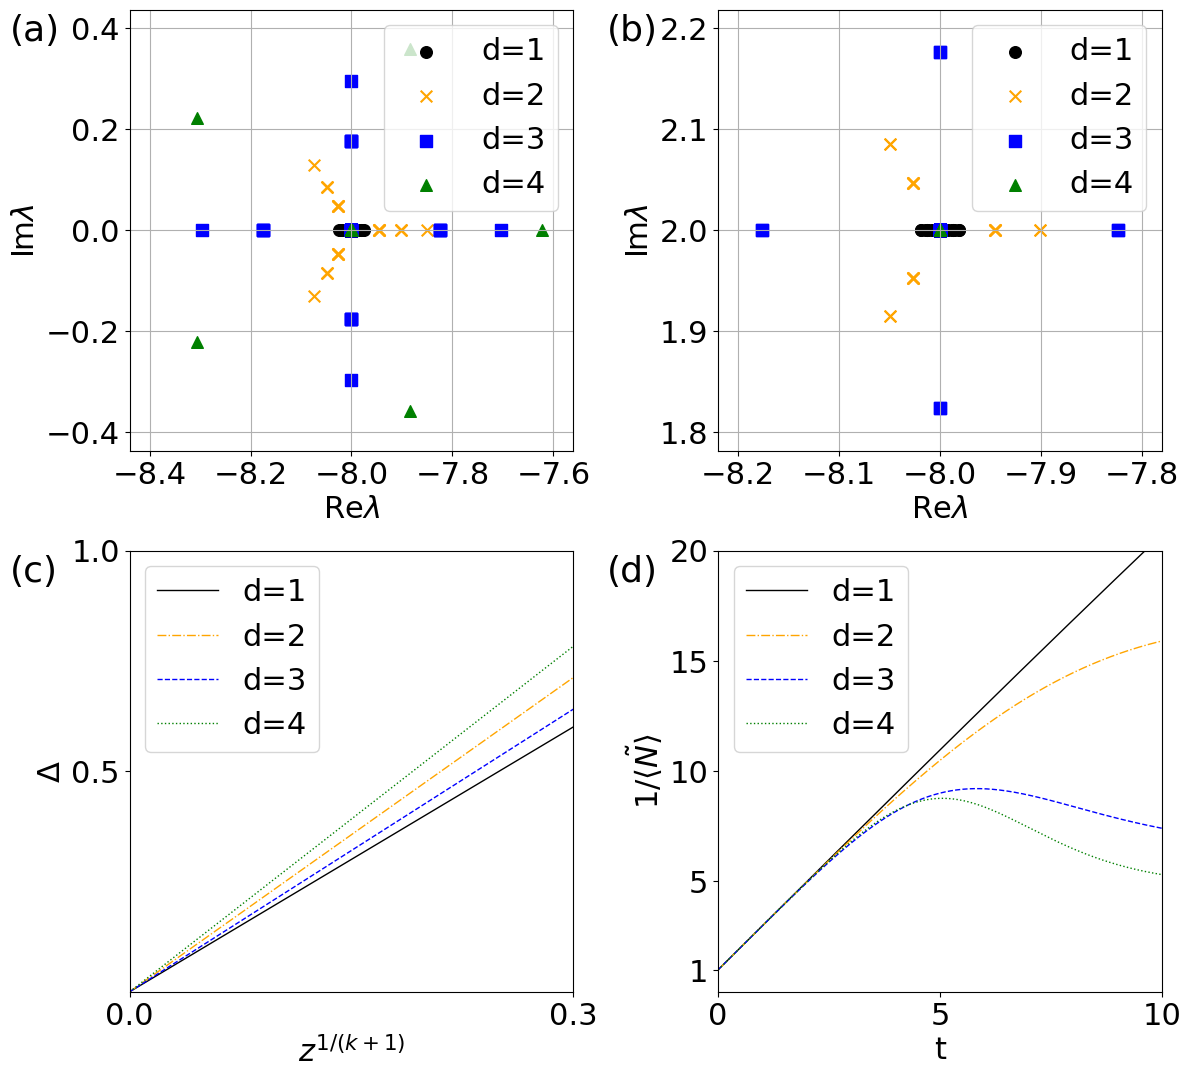

In [1]:
import numpy as np
import matplotlib.pyplot as plt
s = 22
plt.figure(figsize=(12,11))
s1=70
plt.subplot2grid((2, 2), (0, 0))
plt.text(-0.27, 0.93, "(a)", transform=plt.gca().transAxes, fontsize=s+4)
data = np.loadtxt('Eigenk1.txt', dtype=complex)
data1 = np.loadtxt('Eigenk2.txt', dtype=complex)
data2 = np.loadtxt('Eigenk3.txt', dtype=complex)
data3 = np.loadtxt('Eigenk4.txt', dtype=complex)
plt.scatter(np.real(data)-8, np.imag(data), s=s1, color='black', label='d=1', marker='o', alpha=1)
plt.scatter(np.real(data1)-8, np.imag(data1), s=s1, color='orange', label='d=2', marker='x', alpha=1)
plt.scatter(np.real(data2)-8, np.imag(data2), s=s1, color='blue', label='d=3', marker='s', alpha=1)
plt.scatter(np.real(data3)-8, np.imag(data3), s=s1, color='green', label='d=4', marker='^', alpha=1)
plt.grid()
plt.axis('equal')
plt.legend(fontsize=s)
plt.xlim(-8.4,-7.6)
plt.xticks([-8.4,-8.2,-8.0,-7.8,-7.6], fontsize=s)
plt.ylim(-0.4,0.4)
plt.yticks([-0.4,-0.2,0,0.2,0.4], fontsize=s)
plt.xlabel('Re$\lambda$', fontsize=s)
plt.ylabel('Im$\lambda$', fontsize=s)


plt.subplot2grid((2, 2), (0, 1))
plt.text(-0.25, 0.93, "(b)", transform=plt.gca().transAxes, fontsize=s+4)
plt.scatter(np.real(data)-8, np.imag(data), s=s1, color='black', label='d=1', marker='o', alpha=1)
plt.scatter(np.real(data1)-8, np.imag(data1), s=s1, color='orange', label='d=2', marker='x', alpha=1)
plt.scatter(np.real(data2)-8, np.imag(data2), s=s1, color='blue', label='d=3', marker='s', alpha=1)
plt.scatter(np.real(data3)-8, np.imag(data3), s=s1, color='green', label='d=4', marker='^', alpha=1)
plt.grid()
plt.axis('equal')
plt.legend(fontsize=s)
plt.xlim(-8.2,-7.8)
plt.xticks([-8.2,-8.1,-8,-7.9,-7.8], fontsize=s)
plt.ylim(1.8,2.2)
plt.yticks([1.8,1.9,2,2.1,2.2], fontsize=s)
plt.xlabel('Re$\lambda$', fontsize=s)
plt.ylabel('Im$\lambda$', fontsize=s)

plt.subplot2grid((2, 2), (1, 0))
q = np.sort(np.array((list(np.arange(0, 0.1, 1e-4)))))
data = np.loadtxt('ReEigenk1.txt', dtype=float)
data1 = np.loadtxt('ReEigenk2.txt', dtype=float)
data2 = np.loadtxt('ReEigenk3.txt', dtype=float)
data3 = np.loadtxt('ReEigenk4.txt', dtype=float)
print(len(q), len(data2))
plt.plot(q**(1/2), data, alpha=1, linewidth=1, color='black', label='d=1')
plt.plot(q**(1/3), data1, alpha=1, linewidth=1, color='orange', linestyle='-.',label='d=2')
plt.plot(q**(1/4), data2, alpha=1, linewidth=1, color='blue', linestyle='--',label='d=3')
plt.plot(q**(1/5), data3, alpha=1, linewidth=1, color='green', linestyle=':',label='d=4')
plt.xlabel('$z^{1/(k+1)}$', fontsize=s)
plt.ylabel('$\Delta$', fontsize=s)
plt.legend(fontsize=s)
plt.ylim(0,1)
plt.xlim(0, 0.3)
plt.xticks([0,0.3], fontsize=s)
plt.yticks([0.5,1], fontsize=s)
plt.text(-0.27, 0.93, "(c)", transform=plt.gca().transAxes, fontsize=s+4)


plt.subplot2grid((2, 2), (1, 1))
t = np.arange(0, 15+1e-2, 1e-2)
n1, n2, n3 = np.loadtxt('1Totnumberk0.txt', dtype=complex), np.loadtxt('1Totnumberk1.txt', dtype=complex), np.loadtxt('1Totnumberk2.txt', dtype=complex)
n4, n5 = np.loadtxt('1Totnumberk3.txt', dtype=complex), np.loadtxt('1Totnumberk4.txt', dtype=complex)
#plt.plot(t, 1/n1, color='gray', linewidth=1.3)
plt.plot(t, 1/n2, color='black', linewidth=1,label='d=1')
plt.plot(t, 1/n3, color='orange', linewidth=1, linestyle='-.',label='d=2')
plt.plot(t, 1/n4, color='blue', linewidth=1, linestyle='--',label='d=3')
plt.plot(t, 1/n5, color='green', linewidth=1, linestyle=':',label='d=4')
plt.xlabel('t', fontsize=s)
plt.ylabel('$1/\\tilde{\langle{N}\\rangle}$', fontsize=s)
plt.xlim(0,10)
plt.ylim(0,20)
plt.xticks([0,5,10], fontsize=s)
plt.yticks([1,5,10,15,20], fontsize=s)
plt.text(-0.25, 0.93, "(d)", transform=plt.gca().transAxes, fontsize=s+4)
plt.tight_layout()
plt.legend(fontsize=s)


plt.savefig('Fig2.pdf', dpi=400)